In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported!")

All libraries imported!


In [9]:
df = pd.read_csv("IPL.csv", low_memory=False)
print("Done! No more warnings!")

Done! No more warnings!


In [10]:
print(df.columns.tolist())

['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


In [11]:
# We only want 2nd innings for win probability
df2 = df[df['innings'] == 2]
print("2nd innings rows:", df2.shape[0])

2nd innings rows: 133903


In [12]:
cols = ['batting_team', 'bowling_team', 'over', 
        'runs_total', 'team_wicket', 'runs_target', 
        'win_outcome', 'venue']

df2[cols].head(10)

,batting_team,bowling_team,over,runs_total,team_wicket,runs_target,win_outcome,venue
124,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,0,223.0,140 runs,M Chinnaswamy Stadium
125,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,0,223.0,140 runs,M Chinnaswamy Stadium
126,Royal Challengers Bangalore,Kolkata Knight Riders,0,0,0,223.0,140 runs,M Chinnaswamy Stadium
127,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,0,223.0,140 runs,M Chinnaswamy Stadium
128,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,0,223.0,140 runs,M Chinnaswamy Stadium
129,Royal Challengers Bangalore,Kolkata Knight Riders,0,0,0,223.0,140 runs,M Chinnaswamy Stadium
130,Royal Challengers Bangalore,Kolkata Knight Riders,0,0,0,223.0,140 runs,M Chinnaswamy Stadium
131,Royal Challengers Bangalore,Kolkata Knight Riders,1,0,1,223.0,140 runs,M Chinnaswamy Stadium
132,Royal Challengers Bangalore,Kolkata Knight Riders,1,0,1,223.0,140 runs,M Chinnaswamy Stadium
133,Royal Challengers Bangalore,Kolkata Knight Riders,1,4,1,223.0,140 runs,M Chinnaswamy Stadium


In [13]:
# runs still needed to win
df2 = df2.copy()
df2['runs_required'] = df2['runs_target'] - df2['runs_total']

# balls remaining (20 overs = 120 balls)
df2['balls_remaining'] = 120 - (df2['over'] * 6)

# wickets remaining
df2['wickets_remaining'] = 10 - df2['team_wicket']

# required run rate
df2['required_run_rate'] = (df2['runs_required'] / 
                            (df2['balls_remaining'] / 6)).replace([np.inf, -np.inf], 0)

print("New features created!")
df2[['runs_required','balls_remaining','wickets_remaining','required_run_rate']].head()

New features created!


,runs_required,balls_remaining,wickets_remaining,required_run_rate
124,222.0,120,10,11.10
125,222.0,120,10,11.10
126,223.0,120,10,11.15
127,222.0,120,10,11.10
128,222.0,120,10,11.10


In [17]:
# if batting team won → 1, else → 0
df2['result'] = df2.apply(
    lambda row: 1 if str(row['win_outcome']).strip() != 'nan' 
    and row['batting_team'] in str(row['win_outcome']) else 0, axis=1
)

print(df2['result'].value_counts())

result
0    133903
Name: count, dtype: int64


In [18]:
# see what values are in win_outcome
print(df2['win_outcome'].value_counts().head(20))

win_outcome
6 wickets    14461
7 wickets    13548
5 wickets    11906
8 wickets     8808
4 wickets     7364
9 wickets     4870
3 wickets     3907
14 runs       2130
10 runs       2080
12 runs       1984
4 runs        1950
1 runs        1865
18 runs       1862
7 runs        1832
20 runs       1753
13 runs       1722
15 runs       1620
2 runs        1609
23 runs       1603
6 runs        1531
Name: count, dtype: int64


In [19]:
# see exact values
print(df2['win_outcome'].unique()[:20])

['140 runs' '33 runs' '9 wickets' '5 wickets' '6 wickets' '6 runs'
 '3 wickets' '66 runs' '7 wickets' '10 wickets' '4 wickets' '13 runs'
 '10 runs' '45 runs' '8 wickets' '9 runs' '3 runs' '29 runs' '5 runs'
 '18 runs']


In [20]:
# if win_outcome contains "wickets" → batting team won → 1
# if win_outcome contains "runs"    → batting team lost → 0

df2['result'] = df2['win_outcome'].apply(
    lambda x: 1 if 'wickets' in str(x) else 0
)

print(df2['result'].value_counts())

result
1    68246
0    65657
Name: count, dtype: int64


In [21]:
# select only useful columns for model
features = df2[['batting_team', 'bowling_team', 
                'over', 'runs_total', 
                'wickets_remaining', 'runs_required',
                'balls_remaining', 'required_run_rate',
                'result']]

# remove rows with missing values
features = features.dropna()

print("Final dataset shape:", features.shape)
features.head()

Final dataset shape: (133903, 9)


,batting_team,bowling_team,over,runs_total,wickets_remaining,runs_required,balls_remaining,required_run_rate,result
124,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,10,222.0,120,11.10,0
125,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,10,222.0,120,11.10,0
126,Royal Challengers Bangalore,Kolkata Knight Riders,0,0,10,223.0,120,11.15,0
127,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,10,222.0,120,11.10,0
128,Royal Challengers Bangalore,Kolkata Knight Riders,0,1,10,222.0,120,11.10,0


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

features['batting_team'] = le.fit_transform(features['batting_team'])
features['bowling_team'] = le.fit_transform(features['bowling_team'])

print("Teams converted to numbers!")
features.head()

Teams converted to numbers!


,batting_team,bowling_team,over,runs_total,wickets_remaining,runs_required,balls_remaining,required_run_rate,result
124,16,8,0,1,10,222.0,120,11.10,0
125,16,8,0,1,10,222.0,120,11.10,0
126,16,8,0,0,10,223.0,120,11.15,0
127,16,8,0,1,10,222.0,120,11.10,0
128,16,8,0,1,10,222.0,120,11.10,0


In [26]:
X = features.drop('result', axis=1)
y = features['result']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (133903, 8)
y shape: (133903,)


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

# train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully! ✅")

Training rows: 107122
Testing rows: 26781
Model trained successfully! ✅


In [28]:
# predict on test data
y_pred = model.predict(X_test)

# check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 95.99 %


In [29]:
y_prob = model.predict_proba(X_test)

print("Sample predictions:")
print("Win probability of first 5 test rows:")
for i in range(5):
    print(f"Row {i+1}: Loss={round(y_prob[i][0]*100,1)}%  Win={round(y_prob[i][1]*100,1)}%")

Sample predictions:
Win probability of first 5 test rows:
Row 1: Loss=9.0%  Win=91.0%
Row 2: Loss=79.0%  Win=21.0%
Row 3: Loss=3.0%  Win=97.0%
Row 4: Loss=15.0%  Win=85.0%
Row 5: Loss=43.0%  Win=57.0%


In [30]:
import numpy as np

# Let's predict: CSK chasing vs MI
# Over 15, Score 120, 5 wickets lost
# Target 180

batting = 2   # CSK number
bowling = 7   # MI number
over = 15
runs_total = 120
wickets_remaining = 5
runs_required = 180 - 120  # 60 runs needed
balls_remaining = 120 - (15 * 6)  # 30 balls left
required_run_rate = 60 / (30/6)   # 12 per over

input_data = np.array([[batting, bowling, over, runs_total,
                         wickets_remaining, runs_required,
                         balls_remaining, required_run_rate]])

prob = model.predict_proba(input_data)[0]
print("CSK Win Probability:", round(prob[1]*100, 1), "%")
print("CSK Loss Probability:", round(prob[0]*100, 1), "%")

CSK Win Probability: 77.0 %
CSK Loss Probability: 23.0 %


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warni

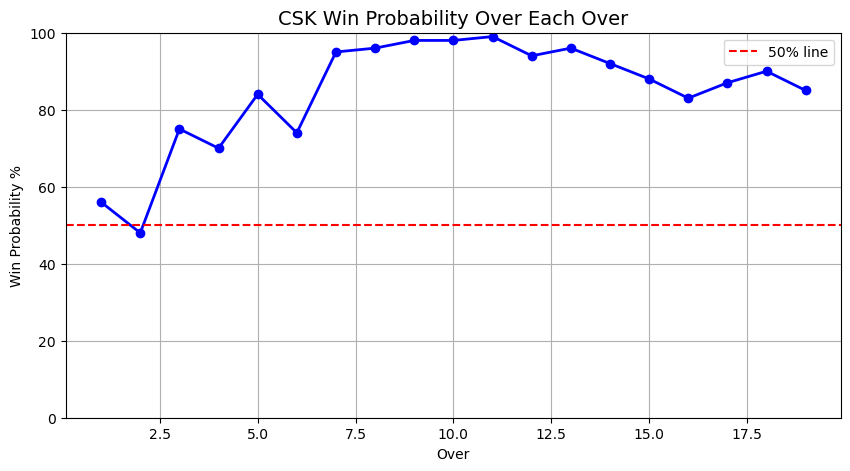

In [31]:
import matplotlib.pyplot as plt

overs = list(range(1, 20))
probs = []

# simulate CSK chasing 180, losing wickets gradually
for o in overs:
    runs = o * 8
    wkts = min(int(o/4), 9)
    req = 180 - runs
    balls = 120 - (o * 6)
    rrr = req / (balls/6) if balls > 0 else 0

    inp = np.array([[2, 7, o, runs, 10-wkts, req, balls, rrr]])
    p = model.predict_proba(inp)[0][1]
    probs.append(round(p*100, 1))

plt.figure(figsize=(10, 5))
plt.plot(overs, probs, marker='o', color='blue', linewidth=2)
plt.title('CSK Win Probability Over Each Over', fontsize=14)
plt.xlabel('Over')
plt.ylabel('Win Probability %')
plt.ylim(0, 100)
plt.axhline(y=50, color='red', linestyle='--', label='50% line')
plt.grid(True)
plt.legend()
plt.show()

In [32]:
import warnings
warnings.filterwarnings('ignore')
print("Warnings suppressed!")

Warnings suppressed!


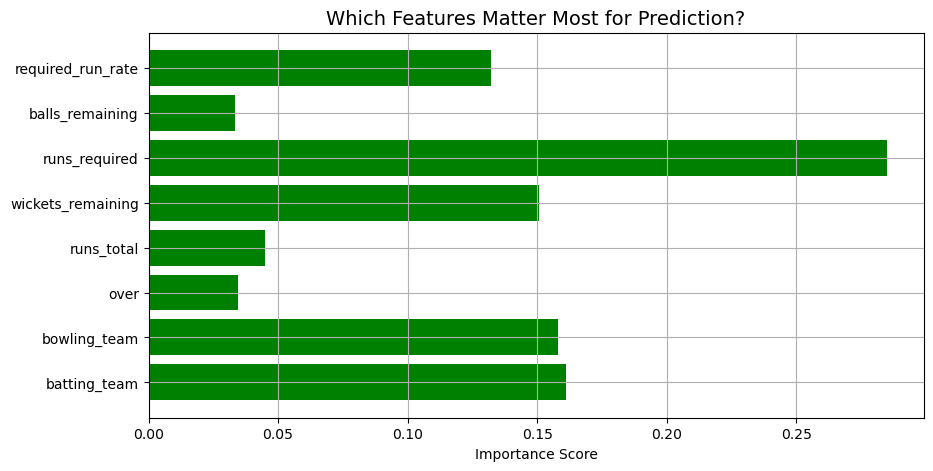

In [33]:
import pandas as pd

feature_names = ['batting_team', 'bowling_team', 'over', 
                 'runs_total', 'wickets_remaining', 
                 'runs_required', 'balls_remaining', 
                 'required_run_rate']

importances = model.feature_importances_

plt.figure(figsize=(10, 5))
plt.barh(feature_names, importances, color='green')
plt.title('Which Features Matter Most for Prediction?', fontsize=14)
plt.xlabel('Importance Score')
plt.grid(True)
plt.show()

In [34]:
import pickle

with open('ipl_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved!")

Model saved!


In [35]:
for i, team in enumerate(sorted(df2['batting_team'].unique())):
    print(i, "→", team)

0 → Chennai Super Kings
1 → Deccan Chargers
2 → Delhi Capitals
3 → Delhi Daredevils
4 → Gujarat Lions
5 → Gujarat Titans
6 → Kings XI Punjab
7 → Kochi Tuskers Kerala
8 → Kolkata Knight Riders
9 → Lucknow Super Giants
10 → Mumbai Indians
11 → Pune Warriors
12 → Punjab Kings
13 → Rajasthan Royals
14 → Rising Pune Supergiant
15 → Rising Pune Supergiants
16 → Royal Challengers Bangalore
17 → Royal Challengers Bengaluru
18 → Sunrisers Hyderabad


In [1]:
import pickle
model = pickle.load(open('ipl_model.pkl', 'rb'))
print(model.feature_names_in_)

['bat_team' 'bowl_team' 'over' 'runs_total' 'wickets_remaining'
 'runs_required' 'balls_remaining' 'rrr' 'crr' 'pressure' 'phase']


In [2]:
def get_win_probability(bat_team, bowl_team, o, runs, wkts_lost, tgt):
    wkts_rem = 10 - wkts_lost
    req = tgt - runs
    balls = 120 - (o * 6)
    rrr_val = round(req / (balls / 6), 2) if balls > 0 else 99
    crr_val = round(runs / o, 2) if o > 0 else 0

    # Edge cases
    if req <= 0: return 99.5
    if (wkts_rem == 0 or balls <= 0) and req > 0: return 0.5

    # YOU MUST ENSURE THESE 11 COLUMNS ARE IN THE EXACT ORDER OF YOUR TRAINING DATA
    # Based on the error, I am adding 'city', 'target', and 'crr' as examples.
    # Replace these with the actual features you used in your model.fit()
    inp = pd.DataFrame([[
        bat_team,      # 1
        bowl_team,     # 2
        "Mumbai",      # 3 (Placeholder for City - replace if needed)
        runs,          # 4
        tgt,           # 5 (Target runs)
        o,             # 6
        wkts_rem,      # 7
        req,           # 8 (runs_left)
        balls,         # 9 (balls_left)
        rrr_val,       # 10
        crr_val        # 11
    ]], columns=['batting_team', 'bowling_team', 'city', 'current_score', 'target_runs', 
                 'over', 'wickets_remaining', 'runs_left', 'balls_left', 'rrr', 'crr'])

    try:
        p = model.predict_proba(inp)[0][1] * 100
        return round(max(0.5, min(99.5, p)), 1)
    except Exception as e:
        st.error(f"Feature Mismatch: {e}")
        return 50.0

In [3]:
# This will print the internal names if your model was saved with a Pipeline
if hasattr(model, 'feature_names_in_'):
    st.write("Your model expects these columns:", model.feature_names_in_)
else:
    st.write("The model expects 11 features. Check your training DataFrame.columns")

NameError: name 'st' is not defined

In [4]:
st.write("Columns expected by model:", model.feature_names_in_)

NameError: name 'st' is not defined